# Análise: Melhor 18º Número para Pool de 17

## Objetivo
Analisar qual número adicional (dos 8 restantes) forma a melhor combinação de 18 números quando combinado com o pool base de 17 números: **2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 16, 17, 20, 22, 23, 24**

Vamos testar cada número restante e verificar quantos acertos de **15, 14 e 13 pontos** cada combinação teria com base nos sorteios históricos.

In [1]:
# Importar bibliotecas necessárias
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo dos gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Carregar Dados Históricos

In [2]:
# Carregar dados históricos da Lotofácil
df = pd.read_csv('data/lotofacil_sorteios.csv')

# Visualizar primeiras linhas
print(f"Total de sorteios: {len(df)}")
print(f"\nPrimeiros sorteios:")
df.head()

Total de sorteios: 3581

Primeiros sorteios:


,Concurso,Data Sorteio,Bola1,Bola2,Bola3,Bola4,Bola5,Bola6,Bola7,Bola8,...,Rateio 13 acertos,Ganhadores 12 acertos,Rateio 12 acertos,Ganhadores 11 acertos,Rateio 11 acertos,Acumulado 15 acertos,Arrecadacao Total,Estimativa Prêmio,Acumulado sorteio especial Lotofácil da Independência,Observação
0,1,29/09/2003,2,3,5,6,9,10,11,13,...,"R$10,00",48807,"R$4,00",257593,"R$2,00","R$0,00","R$0,00","R$0,00","R$0,00",Estimativa de prêmio (15 ACERTOS) próximo conc...
1,2,06/10/2003,1,4,5,6,7,9,11,12,...,"R$10,00",81252,"R$4,00",478188,"R$2,00","R$0,00","R$0,00","R$0,00","R$0,00",ESTIMATIVA DE PRÊMIO PARA O PRÓXIMO CONCURSO (...
2,3,13/10/2003,1,4,6,7,8,9,10,11,...,"R$10,00",96244,"R$4,00",608211,"R$2,00","R$0,00","R$0,00","R$0,00","R$0,00",Estimativa de prêmio (15 ACERTOS) próximo conc...
3,4,20/10/2003,1,2,4,5,8,10,12,13,...,"R$10,00",123912,"R$4,00",706657,"R$2,00","R$0,00","R$0,00","R$0,00","R$0,00",Estimativa de prêmio (15 ACERTOS) próximo conc...
4,5,27/10/2003,1,2,4,8,9,11,12,13,...,"R$10,00",195636,"R$4,00",860992,"R$2,00","R$0,00","R$0,00","R$0,00","R$0,00",Estimativa de prêmio para o próximo concurso (...


## 2. Definir Pool Base e Números Restantes

In [12]:
# Pool base de 17 números
#pool_base = [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 16, 17, 20, 22, 23, 24]''
pool_base = [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 16, 17, 19, 20, 22, 23, 24]
# Todos os números possíveis da Lotofácil (1 a 25)
todos_numeros = set(range(1, 26))

# Números restantes (não estão no pool base)
numeros_restantes = sorted(todos_numeros - set(pool_base))

print(f"Pool Base ({len(pool_base)} números): {pool_base}")
print(f"\nNúmeros Restantes ({len(numeros_restantes)} números): {numeros_restantes}")
print(f"\nVamos testar qual desses {len(numeros_restantes)} números forma a melhor combinação de 18!")

Pool Base (17 números): [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 16, 17, 19, 20, 22, 23, 24]

Números Restantes (8 números): [1, 9, 11, 13, 14, 18, 21, 25]

Vamos testar qual desses 8 números forma a melhor combinação de 18!


## 3. Função para Calcular Acertos

In [13]:
def calcular_acertos_pool(pool_18, df):
    """
    Calcula quantos acertos de 15, 14 e 13 pontos um pool de 18 números teve
    em todos os sorteios históricos.
    
    Args:
        pool_18: Lista com 18 números
        df: DataFrame com os sorteios históricos
        
    Returns:
        Dicionário com contagem de acertos por categoria
    """
    pool_set = set(pool_18)
    acertos = {15: 0, 14: 0, 13: 0}
    detalhes_acertos = []
    
    for idx, row in df.iterrows():
        # Extrair os números do sorteio
        sorteio = []
        for col in df.columns:
            if col.startswith('Bola'):
                sorteio.append(row[col])
        
        # Calcular quantos números do pool estão no sorteio
        sorteio_set = set(sorteio)
        num_acertos = len(pool_set & sorteio_set)
        
        # Registrar se teve 15, 14 ou 13 acertos
        if num_acertos in acertos:
            acertos[num_acertos] += 1
            detalhes_acertos.append({
                'Concurso': row['Concurso'],
                'Acertos': num_acertos,
                'Data': row['Data Sorteio'] if 'Data Sorteio' in row else 'N/A'
            })
    
    return acertos, detalhes_acertos

print("Função criada com sucesso!")

Função criada com sucesso!


## 4. Testar Cada Número Restante

In [14]:
# Dicionário para armazenar resultados
resultados = {}

print("Testando cada número restante...\n")
print("=" * 80)

for num in numeros_restantes:
    # Criar pool de 18 números (pool base + número testado)
    pool_18 = sorted(pool_base + [num])
    
    # Calcular acertos
    acertos, detalhes = calcular_acertos_pool(pool_18, df)
    
    # Armazenar resultados
    resultados[num] = {
        'acertos_15': acertos[15],
        'acertos_14': acertos[14],
        'acertos_13': acertos[13],
        'total_premiacoes': acertos[15] + acertos[14] + acertos[13],
        'detalhes': detalhes
    }
    
    # Mostrar progresso
    print(f"Número {num:2d}: 15 pts = {acertos[15]:2d} | 14 pts = {acertos[14]:3d} | 13 pts = {acertos[13]:4d} | Total = {acertos[15] + acertos[14] + acertos[13]:4d}")

print("=" * 80)
print("\nAnálise concluída!")

Testando cada número restante...

Número  1: 15 pts =  3 | 14 pts =  19 | 13 pts =  154 | Total =  176
Número  9: 15 pts =  3 | 14 pts =  15 | 13 pts =  156 | Total =  174
Número 11: 15 pts =  2 | 14 pts =  22 | 13 pts =  162 | Total =  186
Número 13: 15 pts =  3 | 14 pts =  18 | 13 pts =  162 | Total =  183
Número 14: 15 pts =  3 | 14 pts =  17 | 13 pts =  177 | Total =  197
Número 18: 15 pts =  2 | 14 pts =  14 | 13 pts =  172 | Total =  188
Número 21: 15 pts =  2 | 14 pts =  15 | 13 pts =  167 | Total =  184
Número 25: 15 pts =  3 | 14 pts =  21 | 13 pts =  176 | Total =  200

Análise concluída!


## 5. Criar DataFrame com Resultados

In [16]:
# Criar DataFrame com os resultados
df_resultados = pd.DataFrame([
    {
        'Número': num,
        'Acertos 15': res['acertos_15'],
        'Acertos 14': res['acertos_14'],
        'Acertos 13': res['acertos_13'],
        'Total Premiações': res['total_premiacoes']
    }
    for num, res in resultados.items()
])

# Ordenar por 15 pontos primeiro, depois 14, depois 13 (todos decrescente)
df_resultados = df_resultados.sort_values(['Acertos 15', 'Acertos 14', 'Acertos 13'], 
                                           ascending=[False, False, False]).reset_index(drop=True)

# Adicionar ranking
df_resultados.insert(0, 'Ranking', range(1, len(df_resultados) + 1))

print("Resultados ordenados por melhor desempenho:\n")
print(df_resultados.to_string(index=False))

Resultados ordenados por melhor desempenho:

 Ranking  Número  Acertos 15  Acertos 14  Acertos 13  Total Premiações
       1      25           3          21         176               200
       2       1           3          19         154               176
       3      13           3          18         162               183
       4      14           3          17         177               197
       5       9           3          15         156               174
       6      11           2          22         162               186
       7      21           2          15         167               184
       8      18           2          14         172               188


## 6. Identificar o Melhor Número

In [17]:
# Identificar o melhor número
melhor_numero = df_resultados.iloc[0]['Número']
melhor_resultado = resultados[melhor_numero]

print("=" * 80)
print("🏆 MELHOR NÚMERO PARA COMPLETAR O POOL DE 18")
print("=" * 80)
print(f"\n✅ Número: {melhor_numero}")
print(f"\n📊 Desempenho:")
print(f"   • Acertos de 15 pontos: {melhor_resultado['acertos_15']}")
print(f"   • Acertos de 14 pontos: {melhor_resultado['acertos_14']}")
print(f"   • Acertos de 13 pontos: {melhor_resultado['acertos_13']}")
print(f"   • Total de premiações: {melhor_resultado['total_premiacoes']}")

print(f"\n🎯 Pool Completo de 18 Números:")
pool_vencedor = sorted(pool_base + [melhor_numero])
print(f"   {pool_vencedor}")
print("=" * 80)

🏆 MELHOR NÚMERO PARA COMPLETAR O POOL DE 18

✅ Número: 25

📊 Desempenho:
   • Acertos de 15 pontos: 3
   • Acertos de 14 pontos: 21
   • Acertos de 13 pontos: 176
   • Total de premiações: 200

🎯 Pool Completo de 18 Números:
   [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 16, 17, 19, 20, 22, 23, 24, np.int64(25)]


## 7. Visualizações

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_26216\9926243.py:47: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


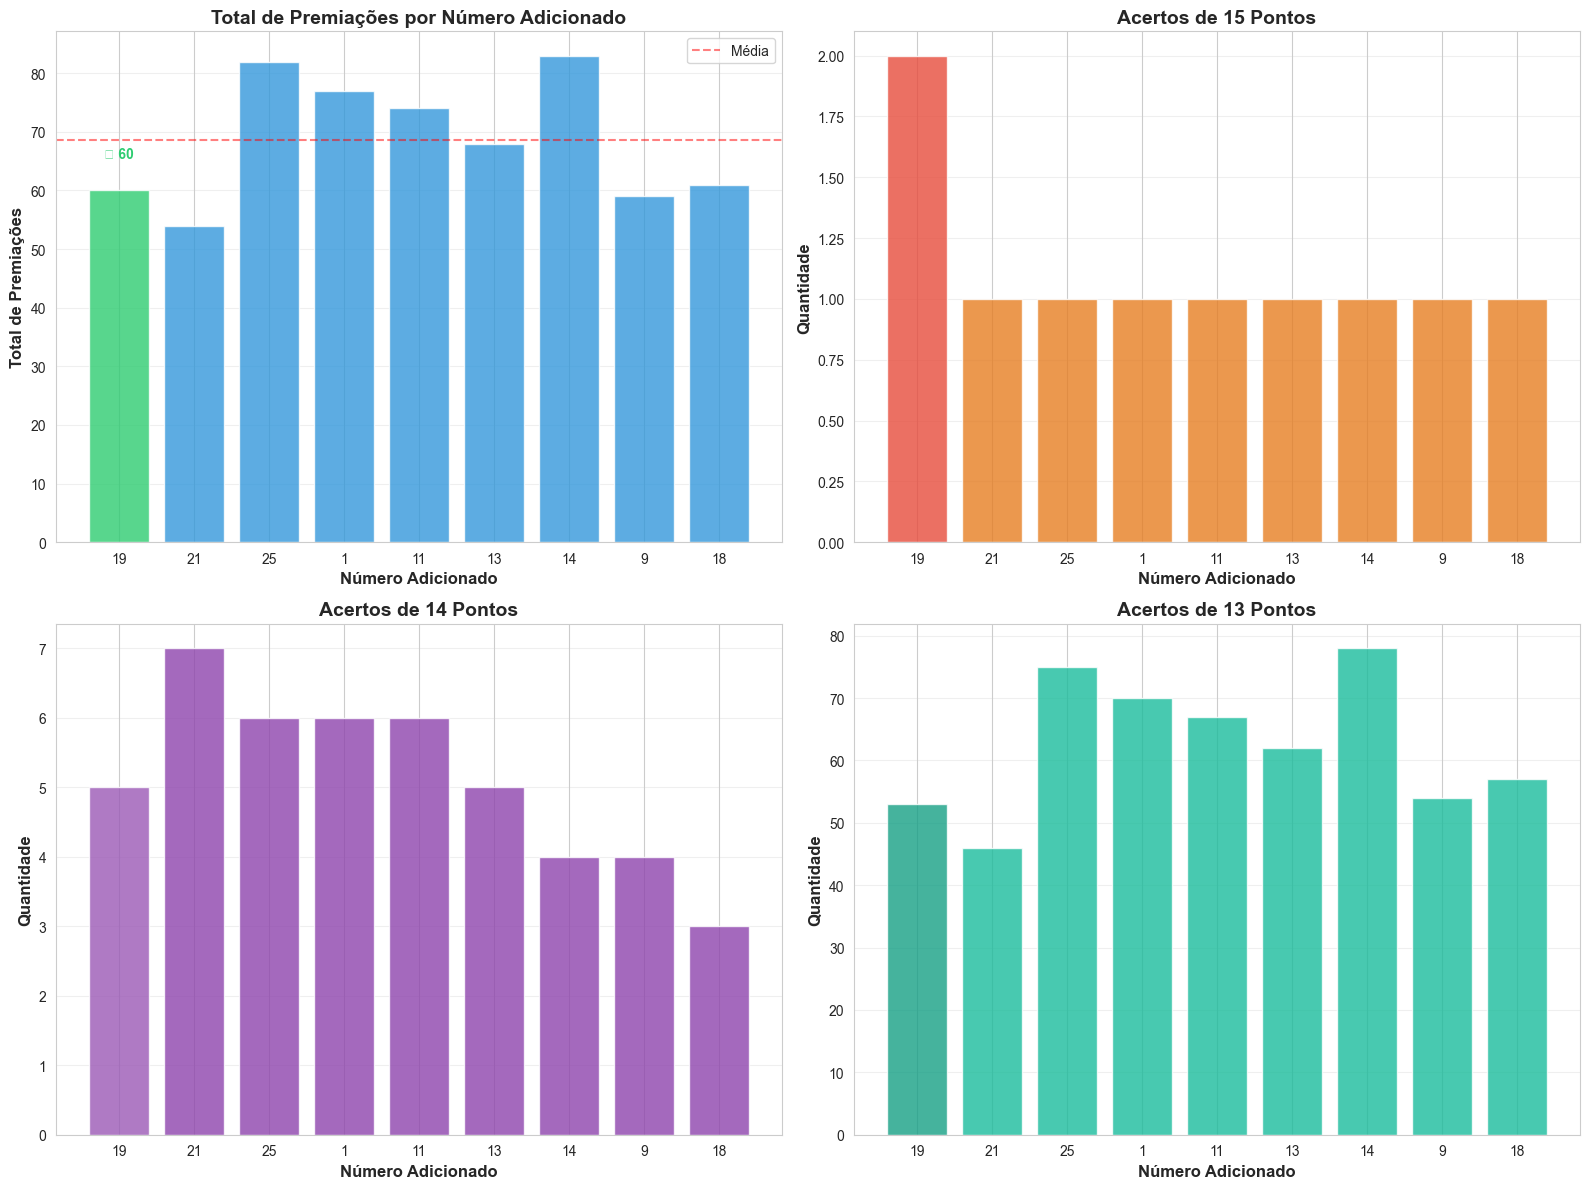

In [11]:
# Gráfico 1: Total de Premiações por Número
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Total de premiações
ax1 = axes[0, 0]
colors = ['#2ecc71' if num == melhor_numero else '#3498db' for num in df_resultados['Número']]
bars = ax1.bar(df_resultados['Número'].astype(str), df_resultados['Total Premiações'], color=colors, alpha=0.8)
ax1.set_xlabel('Número Adicionado', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total de Premiações', fontsize=12, fontweight='bold')
ax1.set_title('Total de Premiações por Número Adicionado', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=df_resultados['Total Premiações'].mean(), color='red', linestyle='--', alpha=0.5, label='Média')
ax1.legend()

# Destacar o melhor
for i, (num, val) in enumerate(zip(df_resultados['Número'], df_resultados['Total Premiações'])):
    if num == melhor_numero:
        ax1.text(i, val + 5, f'★ {val}', ha='center', va='bottom', fontweight='bold', fontsize=10, color='#2ecc71')

# Acertos de 15 pontos
ax2 = axes[0, 1]
colors_15 = ['#e74c3c' if num == melhor_numero else '#e67e22' for num in df_resultados['Número']]
ax2.bar(df_resultados['Número'].astype(str), df_resultados['Acertos 15'], color=colors_15, alpha=0.8)
ax2.set_xlabel('Número Adicionado', fontsize=12, fontweight='bold')
ax2.set_ylabel('Quantidade', fontsize=12, fontweight='bold')
ax2.set_title('Acertos de 15 Pontos', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Acertos de 14 pontos
ax3 = axes[1, 0]
colors_14 = ['#9b59b6' if num == melhor_numero else '#8e44ad' for num in df_resultados['Número']]
ax3.bar(df_resultados['Número'].astype(str), df_resultados['Acertos 14'], color=colors_14, alpha=0.8)
ax3.set_xlabel('Número Adicionado', fontsize=12, fontweight='bold')
ax3.set_ylabel('Quantidade', fontsize=12, fontweight='bold')
ax3.set_title('Acertos de 14 Pontos', fontsize=14, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Acertos de 13 pontos
ax4 = axes[1, 1]
colors_13 = ['#16a085' if num == melhor_numero else '#1abc9c' for num in df_resultados['Número']]
ax4.bar(df_resultados['Número'].astype(str), df_resultados['Acertos 13'], color=colors_13, alpha=0.8)
ax4.set_xlabel('Número Adicionado', fontsize=12, fontweight='bold')
ax4.set_ylabel('Quantidade', fontsize=12, fontweight='bold')
ax4.set_title('Acertos de 13 Pontos', fontsize=14, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Gráfico 2: Comparação detalhada dos Top 5
top5 = df_resultados.head(5)

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(top5))
width = 0.25

bars1 = ax.bar(x - width, top5['Acertos 15'], width, label='15 pontos', color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x, top5['Acertos 14'], width, label='14 pontos', color='#9b59b6', alpha=0.8)
bars3 = ax.bar(x + width, top5['Acertos 13'], width, label='13 pontos', color='#16a085', alpha=0.8)

ax.set_xlabel('Número Adicionado', fontsize=12, fontweight='bold')
ax.set_ylabel('Quantidade de Acertos', fontsize=12, fontweight='bold')
ax.set_title('Top 5 Números - Comparação Detalhada de Acertos', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top5['Número'].astype(str), fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}',
                   ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Detalhes dos Sorteios com Melhor Desempenho

In [ ]:
# Mostrar detalhes dos sorteios que tiveram 15 pontos com o melhor número
detalhes_15 = [d for d in melhor_resultado['detalhes'] if d['Acertos'] == 15]

if detalhes_15:
    print(f"🎯 Sorteios que teriam 15 PONTOS com o pool completo (número {melhor_numero}):\n")
    df_15 = pd.DataFrame(detalhes_15)
    print(df_15.to_string(index=False))
else:
    print(f"⚠️  Não houve sorteios com 15 pontos para o número {melhor_numero}")

In [ ]:
# Mostrar alguns exemplos de sorteios com 14 pontos
detalhes_14 = [d for d in melhor_resultado['detalhes'] if d['Acertos'] == 14]

if detalhes_14:
    print(f"\n📊 Primeiros 10 sorteios com 14 PONTOS (número {melhor_numero}):\n")
    df_14 = pd.DataFrame(detalhes_14[:10])
    print(df_14.to_string(index=False))
    print(f"\n... e mais {len(detalhes_14) - 10} sorteios com 14 pontos!" if len(detalhes_14) > 10 else "")

## 9. Resumo Final e Recomendação

In [ ]:
print("=" * 80)
print("📋 RESUMO FINAL DA ANÁLISE")
print("=" * 80)

print(f"\n🎲 Pool Base testado: {pool_base}")
print(f"📊 Total de sorteios analisados: {len(df)}")
print(f"🔢 Números testados: {numeros_restantes}")

print(f"\n{'─' * 80}")
print("🏆 RECOMENDAÇÃO FINAL")
print(f"{'─' * 80}")

print(f"\n✅ Melhor número para adicionar: {melhor_numero}")
print(f"\n🎯 Pool completo recomendado de 18 números:")
print(f"   {sorted(pool_base + [melhor_numero])}")

print(f"\n📈 Performance esperada:")
print(f"   • {melhor_resultado['acertos_15']} acertos de 15 pontos")
print(f"   • {melhor_resultado['acertos_14']} acertos de 14 pontos")
print(f"   • {melhor_resultado['acertos_13']} acertos de 13 pontos")
print(f"   • {melhor_resultado['total_premiacoes']} premiações totais")

# Calcular percentual de sorteios premiados
percentual_premiado = (melhor_resultado['total_premiacoes'] / len(df)) * 100
print(f"\n📊 Taxa de premiação: {percentual_premiado:.2f}% dos sorteios")

print(f"\n{'─' * 80}")
print("💡 Top 3 números alternativos:")
for i, row in df_resultados.head(3).iterrows():
    print(f"   {i+1}º) Número {row['Número']}: {row['Total Premiações']} premiações totais")

print("=" * 80)

---

# PARTE 2: Análise de Remoção - Qual Número Remover com Menor Perda?

## Objetivo
Agora vamos analisar o pool de 18 números **[2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 16, 17, 19, 20, 22, 23, 24, 25]** e descobrir qual número podemos **remover** com a **menor perda** de acertos de 15, 14 e 13 pontos.

## 10. Definir Pool de Teste (18 números)

In [18]:
# Pool de teste com 18 números
POOL_TESTE = [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 16, 17, 19, 20, 22, 23, 24, 25]

print(f"Pool de Teste ({len(POOL_TESTE)} números): {POOL_TESTE}")
print(f"\nVamos testar a remoção de cada um desses números para ver qual causa menor perda!")

Pool de Teste (18 números): [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 16, 17, 19, 20, 22, 23, 24, 25]

Vamos testar a remoção de cada um desses números para ver qual causa menor perda!


## 11. Calcular Acertos com Pool Completo (Baseline)

In [19]:
# Calcular acertos com o pool completo de 18 números (baseline)
acertos_baseline, detalhes_baseline = calcular_acertos_pool(POOL_TESTE, df)

print("=" * 80)
print("📊 BASELINE - Pool Completo de 18 Números")
print("=" * 80)
print(f"\nPool: {POOL_TESTE}")
print(f"\n✅ Acertos com pool completo:")
print(f"   • 15 pontos: {acertos_baseline[15]}")
print(f"   • 14 pontos: {acertos_baseline[14]}")
print(f"   • 13 pontos: {acertos_baseline[13]}")
print(f"   • Total: {acertos_baseline[15] + acertos_baseline[14] + acertos_baseline[13]}")
print("=" * 80)

📊 BASELINE - Pool Completo de 18 Números

Pool: [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 16, 17, 19, 20, 22, 23, 24, 25]

✅ Acertos com pool completo:
   • 15 pontos: 3
   • 14 pontos: 21
   • 13 pontos: 176
   • Total: 200


## 12. Testar Remoção de Cada Número

In [20]:
# Testar a remoção de cada número
resultados_remocao = {}

print("\nTestando remoção de cada número...\n")
print("=" * 90)

for num in POOL_TESTE:
    # Criar pool de 17 números (removendo o número testado)
    pool_17 = [n for n in POOL_TESTE if n != num]
    
    # Calcular acertos com o pool reduzido
    acertos, detalhes = calcular_acertos_pool(pool_17, df)
    
    # Calcular perdas em relação ao baseline
    perda_15 = acertos_baseline[15] - acertos[15]
    perda_14 = acertos_baseline[14] - acertos[14]
    perda_13 = acertos_baseline[13] - acertos[13]
    perda_total = (acertos_baseline[15] + acertos_baseline[14] + acertos_baseline[13]) - \
                  (acertos[15] + acertos[14] + acertos[13])
    
    # Armazenar resultados
    resultados_remocao[num] = {
        'acertos_15': acertos[15],
        'acertos_14': acertos[14],
        'acertos_13': acertos[13],
        'perda_15': perda_15,
        'perda_14': perda_14,
        'perda_13': perda_13,
        'perda_total': perda_total,
        'pool_17': pool_17,
        'detalhes': detalhes
    }
    
    # Mostrar progresso
    print(f"Removendo {num:2d}: 15pts={acertos[15]:2d} (⬇{perda_15:2d}) | "
          f"14pts={acertos[14]:3d} (⬇{perda_14:2d}) | "
          f"13pts={acertos[13]:4d} (⬇{perda_13:3d}) | "
          f"Perda Total={perda_total:3d}")

print("=" * 90)
print("\nAnálise de remoção concluída!")


Testando remoção de cada número...

Removendo  2: 15pts= 1 (⬇ 2) | 14pts=  6 (⬇15) | 13pts=  70 (⬇106) | Perda Total=123
Removendo  3: 15pts= 1 (⬇ 2) | 14pts=  9 (⬇12) | 13pts=  63 (⬇113) | Perda Total=127
Removendo  4: 15pts= 1 (⬇ 2) | 14pts=  7 (⬇14) | 13pts=  61 (⬇115) | Perda Total=131
Removendo  5: 15pts= 0 (⬇ 3) | 14pts=  9 (⬇12) | 13pts=  70 (⬇106) | Perda Total=121
Removendo  6: 15pts= 0 (⬇ 3) | 14pts=  9 (⬇12) | 13pts=  59 (⬇117) | Perda Total=132
Removendo  7: 15pts= 0 (⬇ 3) | 14pts= 10 (⬇11) | 13pts=  61 (⬇115) | Perda Total=129
Removendo  8: 15pts= 0 (⬇ 3) | 14pts=  6 (⬇15) | 13pts=  67 (⬇109) | Perda Total=127
Removendo 10: 15pts= 0 (⬇ 3) | 14pts=  5 (⬇16) | 13pts=  68 (⬇108) | Perda Total=127
Removendo 12: 15pts= 0 (⬇ 3) | 14pts=  9 (⬇12) | 13pts=  57 (⬇119) | Perda Total=134
Removendo 15: 15pts= 1 (⬇ 2) | 14pts=  6 (⬇15) | 13pts=  62 (⬇114) | Perda Total=131
Removendo 16: 15pts= 0 (⬇ 3) | 14pts=  8 (⬇13) | 13pts=  66 (⬇110) | Perda Total=126
Removendo 17: 15pts= 0 (⬇ 3)

## 13. Criar DataFrame com Resultados de Remoção

In [21]:
# Criar DataFrame com os resultados de remoção
df_remocao = pd.DataFrame([
    {
        'Número Removido': num,
        'Acertos 15': res['acertos_15'],
        'Perda 15': res['perda_15'],
        'Acertos 14': res['acertos_14'],
        'Perda 14': res['perda_14'],
        'Acertos 13': res['acertos_13'],
        'Perda 13': res['perda_13'],
        'Perda Total': res['perda_total']
    }
    for num, res in resultados_remocao.items()
])

# Ordenar por menor perda de 15 pontos primeiro, depois 14, depois 13
df_remocao = df_remocao.sort_values(['Perda 15', 'Perda 14', 'Perda 13'], 
                                     ascending=[True, True, True]).reset_index(drop=True)

# Adicionar ranking
df_remocao.insert(0, 'Ranking', range(1, len(df_remocao) + 1))

print("\n📊 Resultados ordenados por MENOR PERDA:\n")
print(df_remocao.to_string(index=False))


📊 Resultados ordenados por MENOR PERDA:

 Ranking  Número Removido  Acertos 15  Perda 15  Acertos 14  Perda 14  Acertos 13  Perda 13  Perda Total
       1               25           2         1           5        16          53       123          140
       2               22           1         2          11        10          63       113          125
       3                3           1         2           9        12          63       113          127
       4                4           1         2           7        14          61       115          131
       5               19           1         2           6        15          75       101          118
       6                2           1         2           6        15          70       106          123
       7               15           1         2           6        15          62       114          131
       8               23           1         2           5        16          65       111          129
       9     

## 14. Identificar o Melhor Número para Remover

In [22]:
# Identificar o número com menor impacto ao ser removido
melhor_remover = df_remocao.iloc[0]['Número Removido']
resultado_melhor_remocao = resultados_remocao[melhor_remover]

print("=" * 80)
print("🏆 MELHOR NÚMERO PARA REMOVER (Menor Perda)")
print("=" * 80)
print(f"\n✅ Número que pode ser removido: {melhor_remover}")
print(f"\n📊 Impacto da remoção:")
print(f"   • Perda de acertos de 15 pontos: {resultado_melhor_remocao['perda_15']}")
print(f"   • Perda de acertos de 14 pontos: {resultado_melhor_remocao['perda_14']}")
print(f"   • Perda de acertos de 13 pontos: {resultado_melhor_remocao['perda_13']}")
print(f"   • Perda total de premiações: {resultado_melhor_remocao['perda_total']}")

print(f"\n📈 Acertos após remoção:")
print(f"   • 15 pontos: {resultado_melhor_remocao['acertos_15']} (antes: {acertos_baseline[15]})")
print(f"   • 14 pontos: {resultado_melhor_remocao['acertos_14']} (antes: {acertos_baseline[14]})")
print(f"   • 13 pontos: {resultado_melhor_remocao['acertos_13']} (antes: {acertos_baseline[13]})")

print(f"\n🎯 Pool Recomendado de 17 Números:")
pool_17_recomendado = resultado_melhor_remocao['pool_17']
print(f"   {pool_17_recomendado}")
print("=" * 80)

🏆 MELHOR NÚMERO PARA REMOVER (Menor Perda)

✅ Número que pode ser removido: 25

📊 Impacto da remoção:
   • Perda de acertos de 15 pontos: 1
   • Perda de acertos de 14 pontos: 16
   • Perda de acertos de 13 pontos: 123
   • Perda total de premiações: 140

📈 Acertos após remoção:
   • 15 pontos: 2 (antes: 3)
   • 14 pontos: 5 (antes: 21)
   • 13 pontos: 53 (antes: 176)

🎯 Pool Recomendado de 17 Números:
   [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 16, 17, 19, 20, 22, 23, 24]


## 15. Visualizar Perdas por Remoção

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_26216\333902864.py:52: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


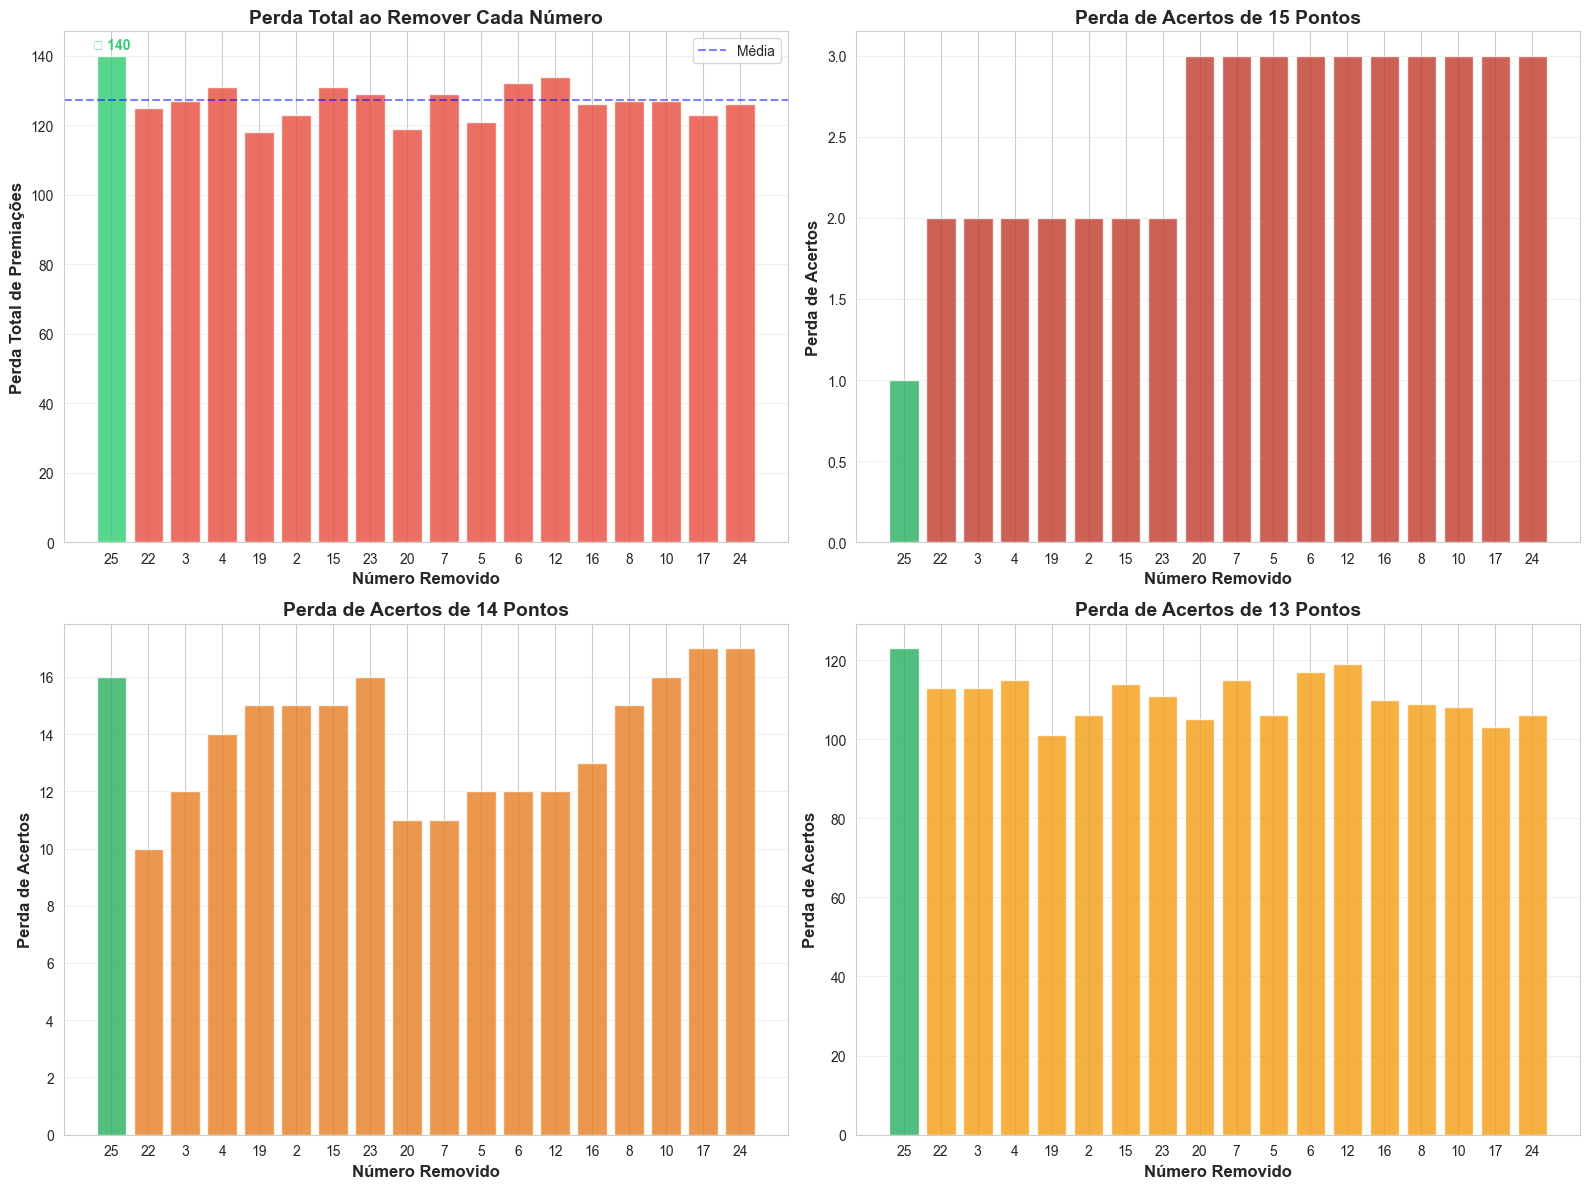

In [23]:
# Gráficos de perda por remoção
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Perda total
ax1 = axes[0, 0]
colors_perda = ['#2ecc71' if num == melhor_remover else '#e74c3c' for num in df_remocao['Número Removido']]
bars = ax1.bar(df_remocao['Número Removido'].astype(str), df_remocao['Perda Total'], 
               color=colors_perda, alpha=0.8)
ax1.set_xlabel('Número Removido', fontsize=12, fontweight='bold')
ax1.set_ylabel('Perda Total de Premiações', fontsize=12, fontweight='bold')
ax1.set_title('Perda Total ao Remover Cada Número', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=df_remocao['Perda Total'].mean(), color='blue', linestyle='--', alpha=0.5, label='Média')
ax1.legend()

# Destacar o melhor
for i, (num, val) in enumerate(zip(df_remocao['Número Removido'], df_remocao['Perda Total'])):
    if num == melhor_remover:
        ax1.text(i, val + 1, f'★ {val}', ha='center', va='bottom', fontweight='bold', 
                fontsize=10, color='#2ecc71')

# Perda de 15 pontos
ax2 = axes[0, 1]
colors_p15 = ['#27ae60' if num == melhor_remover else '#c0392b' for num in df_remocao['Número Removido']]
ax2.bar(df_remocao['Número Removido'].astype(str), df_remocao['Perda 15'], 
        color=colors_p15, alpha=0.8)
ax2.set_xlabel('Número Removido', fontsize=12, fontweight='bold')
ax2.set_ylabel('Perda de Acertos', fontsize=12, fontweight='bold')
ax2.set_title('Perda de Acertos de 15 Pontos', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Perda de 14 pontos
ax3 = axes[1, 0]
colors_p14 = ['#27ae60' if num == melhor_remover else '#e67e22' for num in df_remocao['Número Removido']]
ax3.bar(df_remocao['Número Removido'].astype(str), df_remocao['Perda 14'], 
        color=colors_p14, alpha=0.8)
ax3.set_xlabel('Número Removido', fontsize=12, fontweight='bold')
ax3.set_ylabel('Perda de Acertos', fontsize=12, fontweight='bold')
ax3.set_title('Perda de Acertos de 14 Pontos', fontsize=14, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Perda de 13 pontos
ax4 = axes[1, 1]
colors_p13 = ['#27ae60' if num == melhor_remover else '#f39c12' for num in df_remocao['Número Removido']]
ax4.bar(df_remocao['Número Removido'].astype(str), df_remocao['Perda 13'], 
        color=colors_p13, alpha=0.8)
ax4.set_xlabel('Número Removido', fontsize=12, fontweight='bold')
ax4.set_ylabel('Perda de Acertos', fontsize=12, fontweight='bold')
ax4.set_title('Perda de Acertos de 13 Pontos', fontsize=14, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

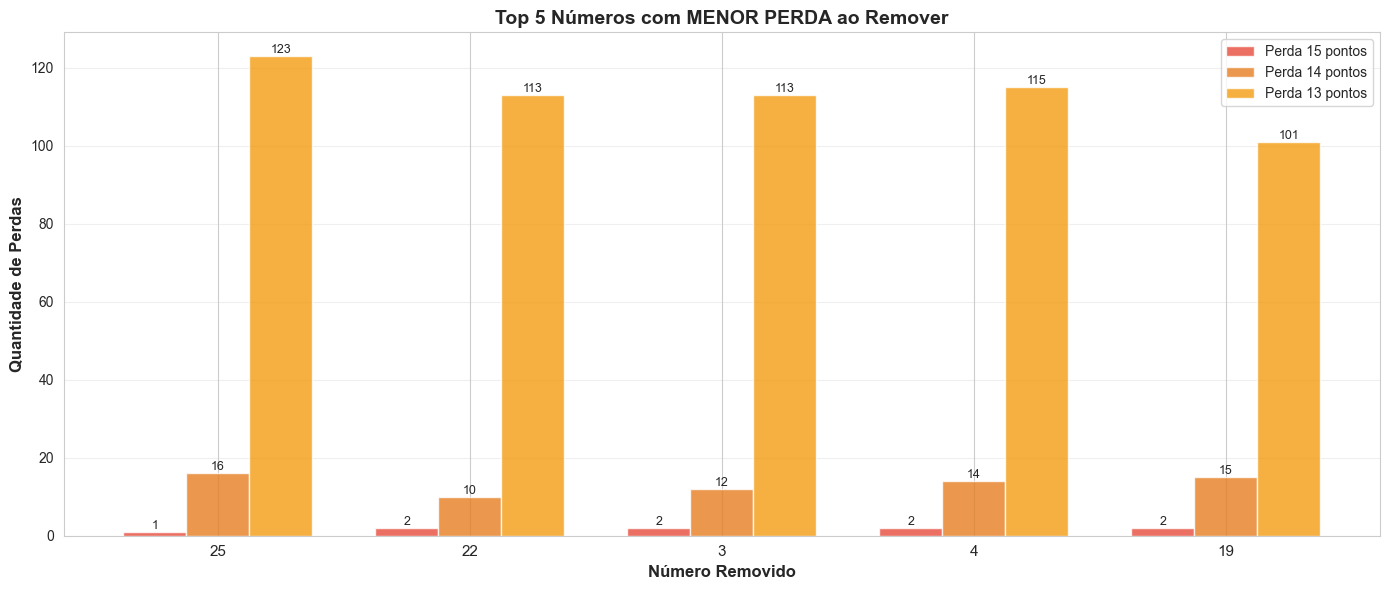

In [24]:
# Gráfico de comparação: Top 5 Melhores para Remover (menor perda)
top5_remover = df_remocao.head(5)

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(top5_remover))
width = 0.25

bars1 = ax.bar(x - width, top5_remover['Perda 15'], width, label='Perda 15 pontos', 
               color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x, top5_remover['Perda 14'], width, label='Perda 14 pontos', 
               color='#e67e22', alpha=0.8)
bars3 = ax.bar(x + width, top5_remover['Perda 13'], width, label='Perda 13 pontos', 
               color='#f39c12', alpha=0.8)

ax.set_xlabel('Número Removido', fontsize=12, fontweight='bold')
ax.set_ylabel('Quantidade de Perdas', fontsize=12, fontweight='bold')
ax.set_title('Top 5 Números com MENOR PERDA ao Remover', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top5_remover['Número Removido'].astype(str), fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}',
                   ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 16. Resumo Final da Análise de Remoção

In [25]:
print("=" * 80)
print("📋 RESUMO FINAL - ANÁLISE DE REMOÇÃO")
print("=" * 80)

print(f"\n🎲 Pool inicial testado (18 números): {POOL_TESTE}")
print(f"📊 Total de sorteios analisados: {len(df)}")

print(f"\n{'─' * 80}")
print("📊 BASELINE - Pool Completo")
print(f"{'─' * 80}")
print(f"   • 15 pontos: {acertos_baseline[15]}")
print(f"   • 14 pontos: {acertos_baseline[14]}")
print(f"   • 13 pontos: {acertos_baseline[13]}")
print(f"   • Total: {acertos_baseline[15] + acertos_baseline[14] + acertos_baseline[13]}")

print(f"\n{'─' * 80}")
print("🏆 RECOMENDAÇÃO - Número para REMOVER")
print(f"{'─' * 80}")

print(f"\n✅ Melhor número para remover: {melhor_remover}")
print(f"\n⬇️  Impacto da remoção (PERDAS):")
print(f"   • Perda de 15 pontos: {resultado_melhor_remocao['perda_15']}")
print(f"   • Perda de 14 pontos: {resultado_melhor_remocao['perda_14']}")
print(f"   • Perda de 13 pontos: {resultado_melhor_remocao['perda_13']}")
print(f"   • Perda total: {resultado_melhor_remocao['perda_total']}")

print(f"\n🎯 Pool recomendado de 17 números:")
print(f"   {pool_17_recomendado}")

print(f"\n📈 Performance após remoção:")
print(f"   • {resultado_melhor_remocao['acertos_15']} acertos de 15 pontos")
print(f"   • {resultado_melhor_remocao['acertos_14']} acertos de 14 pontos")
print(f"   • {resultado_melhor_remocao['acertos_13']} acertos de 13 pontos")
print(f"   • {resultado_melhor_remocao['acertos_15'] + resultado_melhor_remocao['acertos_14'] + resultado_melhor_remocao['acertos_13']} premiações totais")

# Percentual de perda
percentual_perda = (resultado_melhor_remocao['perda_total'] / 
                    (acertos_baseline[15] + acertos_baseline[14] + acertos_baseline[13])) * 100
print(f"\n📉 Taxa de perda: {percentual_perda:.2f}% do total de premiações")

print(f"\n{'─' * 80}")
print("💡 Top 3 piores números para remover (maior perda):")
piores_3 = df_remocao.tail(3).iloc[::-1]  # Inverter para mostrar o pior primeiro
for i, row in piores_3.iterrows():
    print(f"   🚫 Número {row['Número Removido']}: Perda total de {row['Perda Total']} "
          f"({row['Perda 15']} de 15pts, {row['Perda 14']} de 14pts, {row['Perda 13']} de 13pts)")

print("=" * 80)

📋 RESUMO FINAL - ANÁLISE DE REMOÇÃO

🎲 Pool inicial testado (18 números): [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 16, 17, 19, 20, 22, 23, 24, 25]
📊 Total de sorteios analisados: 3581

────────────────────────────────────────────────────────────────────────────────
📊 BASELINE - Pool Completo
────────────────────────────────────────────────────────────────────────────────
   • 15 pontos: 3
   • 14 pontos: 21
   • 13 pontos: 176
   • Total: 200

────────────────────────────────────────────────────────────────────────────────
🏆 RECOMENDAÇÃO - Número para REMOVER
────────────────────────────────────────────────────────────────────────────────

✅ Melhor número para remover: 25

⬇️  Impacto da remoção (PERDAS):
   • Perda de 15 pontos: 1
   • Perda de 14 pontos: 16
   • Perda de 13 pontos: 123
   • Perda total: 140

🎯 Pool recomendado de 17 números:
   [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 16, 17, 19, 20, 22, 23, 24]

📈 Performance após remoção:
   • 2 acertos de 15 pontos
   • 5 acertos de 14 pontos
 